In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR
SRC_DIR = PROJECT_DIR / "src"

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Не найдена папка src: {SRC_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR     =", SRC_DIR)


PROJECT_DIR = C:\Users\timti\PycharmProjects\MastersDegreeObfuscator\NewObfuscator
MODULE_DIR  = C:\Users\timti\PycharmProjects\MastersDegreeObfuscator\NewObfuscator\heatmap


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

from model_service import BertAIDetector, DetectorConfig
from heatmap.analysis import run_heatmap_analysis


In [3]:
INPUT_PATH = Path("data/train_data/Ru-hard-detection-dataset-main/long_sc/paraphrased_generated_articles.json")
OUTPUT_DIR = Path("data/output_data/scientific_heatmap_run")
MODEL_PATH = Path("trained_models/ensemble_models_2_3000/manifest.json")

DETECTOR_TYPE = "ensemble"
DEVICE = "cuda"
TEXT_COL = "text"
ARTICLE_ID_COL = "article_id"
TITLE_COL = None


In [4]:
SUPPORTED_SUFFIXES = {".csv", ".parquet", ".json", ".jsonl", ".txt"}

def load_articles(input_path: str | Path, *, text_col: str, article_id_col: str) -> pd.DataFrame:
    path = Path(input_path)

    if path.is_dir():
        rows = []
        for file_path in sorted(path.glob("*.txt")):
            rows.append({
                article_id_col: file_path.stem,
                text_col: file_path.read_text(encoding="utf-8", errors="ignore"),
            })
        return pd.DataFrame(rows)

    suffix = path.suffix.lower()
    if suffix not in SUPPORTED_SUFFIXES:
        raise ValueError(f"Unsupported file type: {suffix}")

    if suffix == ".csv":
        df = pd.read_csv(path)
    elif suffix == ".parquet":
        df = pd.read_parquet(path)
    elif suffix in {".json", ".jsonl"}:
        df = pd.read_json(path, lines=(suffix == ".jsonl"))
    elif suffix == ".txt":
        df = pd.DataFrame([{
            article_id_col: path.stem,
            text_col: path.read_text(encoding="utf-8", errors="ignore"),
        }])

    if article_id_col not in df.columns:
        df = df.copy()
        df[article_id_col] = [f"article_{i:04d}" for i in range(len(df))]

    if text_col not in df.columns:
        raise ValueError(f"Колонка {text_col!r} не найдена")

    return df

df_articles = load_articles(
    INPUT_PATH,
    text_col=TEXT_COL,
    article_id_col=ARTICLE_ID_COL,
)

print(df_articles.shape)
display(df_articles.head(3))


(1625, 7)


,id,text,model,paraphrasing_type,dataset,source,article_id
0,1,**Алгоритм для встраивания полухрупких цифровы...,chatgpt-4o-mini,DP,Rus scientific articles,ai+rew,article_0000
1,2,**Программные продукты и системы** ...,chatgpt-4o-mini,DP,Rus scientific articles,ai+rew,article_0001
2,3,**Выделение контуров на изображениях с помощью...,chatgpt-4o-mini,DP,Rus scientific articles,ai+rew,article_0002


In [5]:
df_articles = df_articles.copy()
df_articles[TEXT_COL] = df_articles[TEXT_COL].astype(str)
df_articles = df_articles[df_articles[TEXT_COL].str.strip().str.len() > 0].reset_index(drop=True)

print("Число статей:", len(df_articles))
print("Средняя длина текста:", int(df_articles[TEXT_COL].str.len().mean()))


Число статей: 1625
Средняя длина текста: 7811


In [6]:
detector = BertAIDetector(DetectorConfig(
    detector_type=DETECTOR_TYPE,
    model_path=str(MODEL_PATH),
    device=DEVICE,
    max_length=256,
    threshold=0.8,
))

print(type(detector))


Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0420 01:33:26.035000 22832 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


<class 'heatmap.detector.EnsembleAIModel'>


In [7]:
result = run_heatmap_analysis(
    detector=detector,
    df_articles=df_articles,
    out_dir=OUTPUT_DIR,
    text_col=TEXT_COL,
    article_id_col=ARTICLE_ID_COL,
    title_col=TITLE_COL,
    batch_size=64,
    window_size=4,
    min_sentences=3,
    stride=4,
    threshold=0.8,
    max_articles_in_heatmap=50,
)


Chunking articles:   0%|          | 0/1625 [00:00<?, ?it/s]

Detector inference on chunks:   0%|          | 0/453 [00:00<?, ?it/s]

Saving artifacts...


In [8]:
print("=== GLOBAL STATS ===")
for k, v in result["global_stats"].items():
    print(f"{k}: {v}")


=== GLOBAL STATS ===
n_articles: 1625
n_chunks: 28946
mean_p_ai: 0.6341071128845215
median_p_ai: 0.9432666301727295
share_ai_like: 0.5535134388171077
threshold: 0.8
top_article_by_mean_p_ai: article_0169


In [9]:
article_summary = result["article_summary"]
feature_comparison = result["feature_comparison"]

print("=== TOP ARTICLES BY mean_p_ai ===")
display(article_summary.head(10))

print("=== TOP FEATURE DIFFERENCES ===")
display(feature_comparison.head(15))


=== TOP ARTICLES BY mean_p_ai ===


,article_id,n_chunks,mean_p_ai,median_p_ai,max_p_ai,share_ai_like,mean_words,mean_words_per_sentence
0,article_0169,7,1.0,1.0,1.0,1.0,76.428571,19.107143
1,article_0223,3,1.0,1.0,1.0,1.0,76.000000,19.000000
2,article_0276,7,1.0,1.0,1.0,1.0,65.000000,16.250000
3,article_0277,7,1.0,1.0,1.0,1.0,84.428571,21.107143
4,article_0282,6,1.0,1.0,1.0,1.0,88.166667,22.041667
5,article_0317,7,1.0,1.0,1.0,1.0,79.857143,20.821429
6,article_0357,5,1.0,1.0,1.0,1.0,80.600000,20.150000
7,article_0508,7,1.0,1.0,1.0,1.0,79.285714,19.821429
8,article_0690,6,1.0,1.0,1.0,1.0,90.500000,23.555556
9,article_0705,8,1.0,1.0,1.0,1.0,118.625000,30.677083


=== TOP FEATURE DIFFERENCES ===


,feature,high_ai_mean,low_ai_mean,delta_high_minus_low,ratio_high_over_low
0,n_chars,627.334349,226.294991,401.039357,2.772197
1,n_words,74.762547,31.097064,43.665483,2.404167
2,avg_words_per_sentence,18.804286,7.782556,11.021730,2.416210
3,avg_chars_per_word,7.175428,5.099711,2.075717,1.407026
4,repeated_words_ge3,2.196693,0.794473,1.402220,2.764968
5,cyr_ratio,0.936056,0.901383,0.034672,1.038466
6,semicolon_ratio,0.000246,0.000969,-0.000723,0.253568
7,quote_ratio,0.001064,0.002261,-0.001197,0.470412
8,et_al_mentions,0.002901,0.004145,-0.001244,0.699884
9,colon_ratio,0.001050,0.002593,-0.001543,0.404936


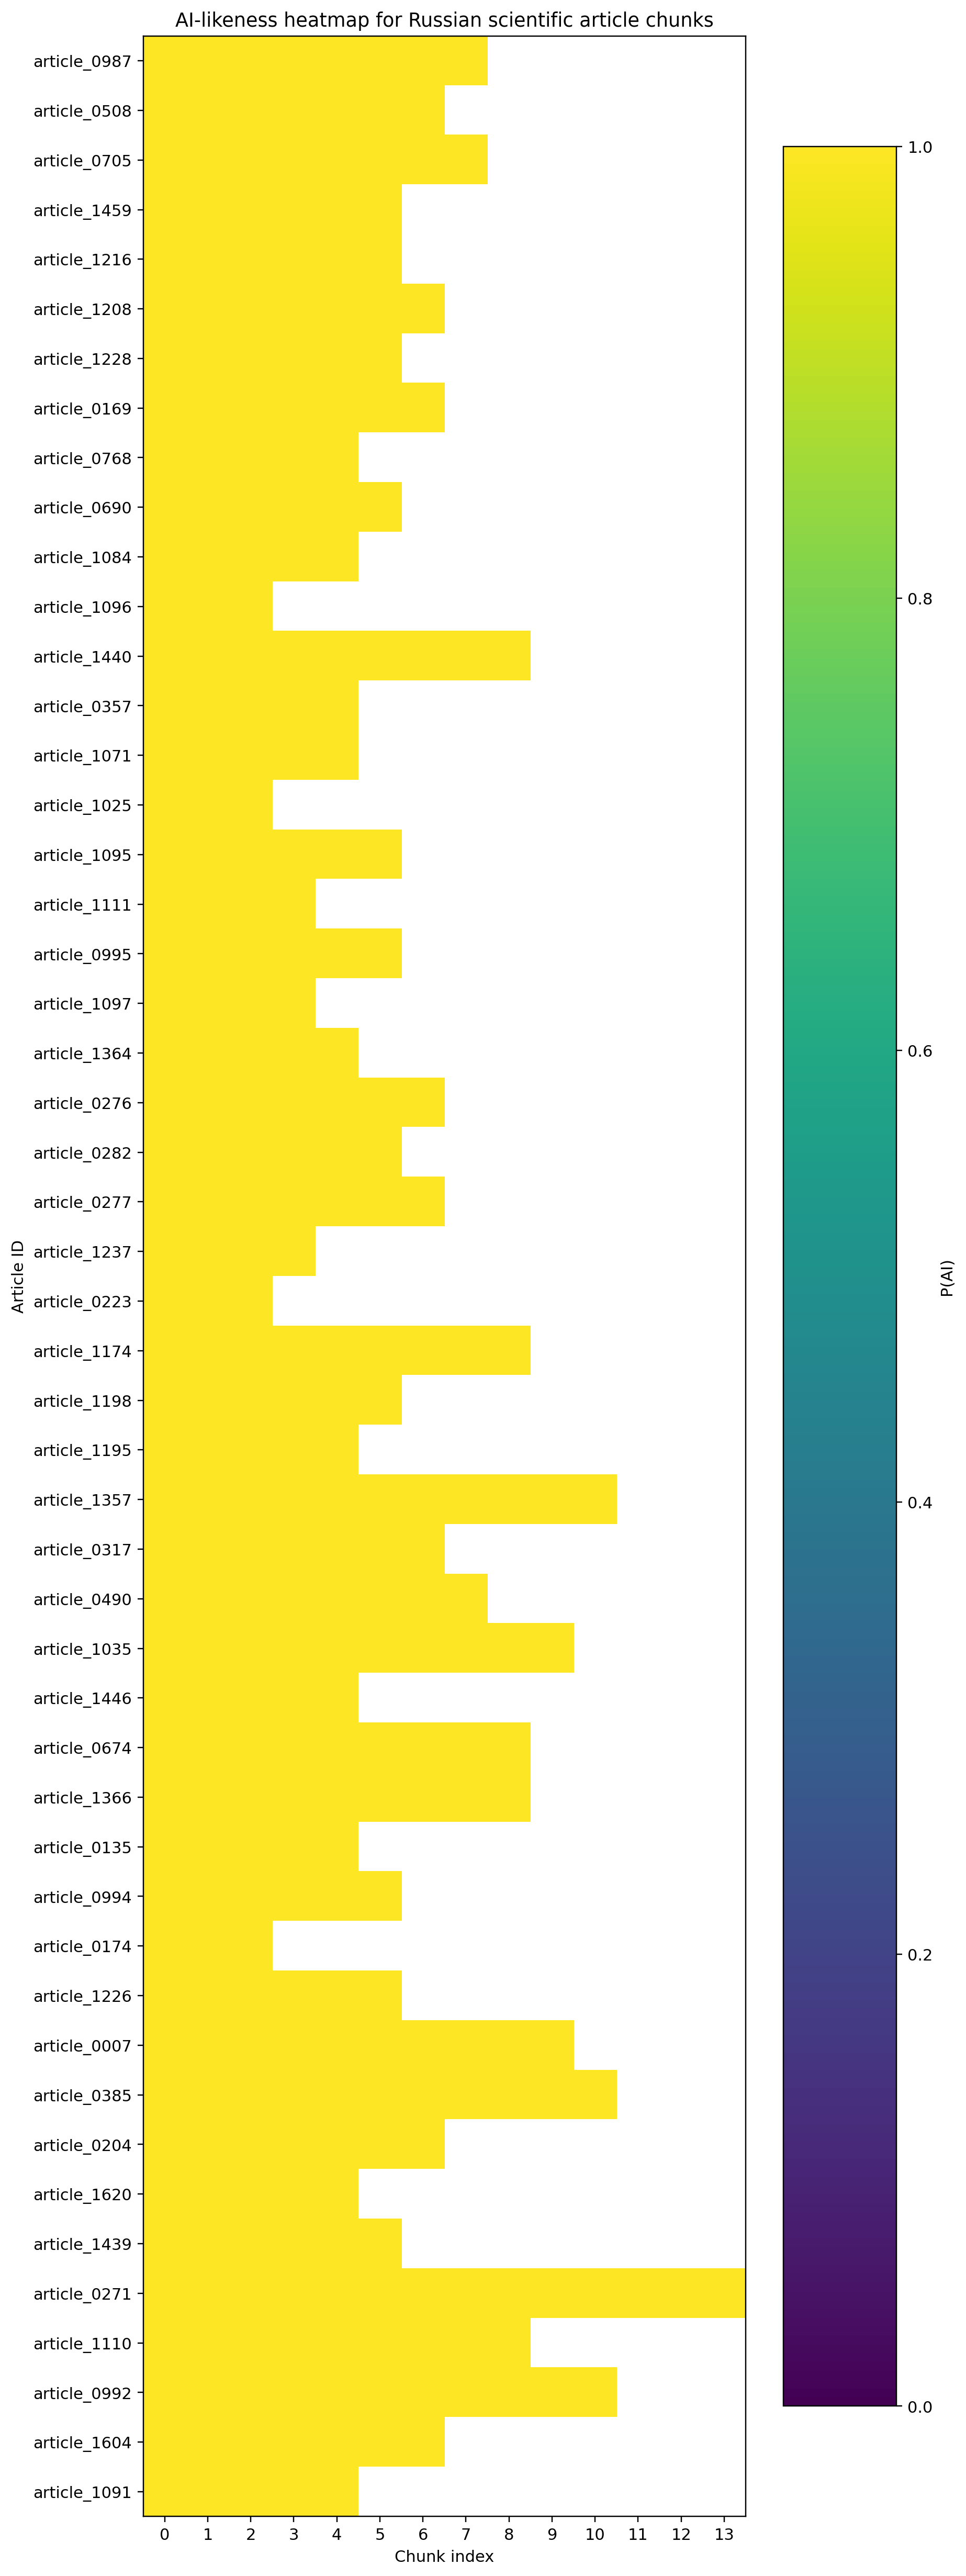

outputs\scientific_heatmap_run\scientific_articles_heatmap.png


In [10]:
artifacts = result["artifacts"]
heatmap_path = artifacts["heatmap_png"]

display(Image(filename=str(heatmap_path)))
print(heatmap_path)


In [13]:
artifacts = result["artifacts"]

chunk_scores_path = artifacts["chunk_scores_csv"]
df_chunks = pd.read_csv(chunk_scores_path)

print(df_chunks.shape)
display(df_chunks.head(3))


(28946, 26)


,article_id,chunk_id,chunk_index,sentence_start,sentence_end,n_sentences,chunk_text,p_ai,is_ai_like,n_chars,...,semicolon_ratio,colon_ratio,dash_ratio,quote_ratio,digit_ratio,cyr_ratio,citation_brackets,year_mentions,et_al_mentions,parenthetical_blocks
0,article_0000,article_0000__chunk_0000,0,0,3,4,**Алгоритм для встраивания полухрупких цифровы...,0.999999,1,149,...,0.0,0.000000,0.000000,0.000000,0.000000,1.0,0,0,0,0
1,article_0000,article_0000__chunk_0001,1,4,7,4,Митекин \nИнститут систем обработки изображен...,1.000000,1,852,...,0.0,0.002347,0.001174,0.002347,0.001174,1.0,1,0,0,3
2,article_0000,article_0000__chunk_0002,2,8,11,4,Принципиально важным аспектом в этих задачах я...,1.000000,1,736,...,0.0,0.000000,0.000000,0.002717,0.000000,1.0,0,0,0,0


In [14]:
cols_to_show = [
    "article_id",
    "chunk_id",
    "chunk_index",
    "p_ai",
    "n_sentences",
    "n_words",
    "avg_words_per_sentence",
    "type_token_ratio",
    "citation_brackets",
    "year_mentions",
    "chunk_text",
]

top_ai = df_chunks.sort_values("p_ai", ascending=False).head(10)
display(top_ai[cols_to_show])


,article_id,chunk_id,chunk_index,p_ai,n_sentences,n_words,avg_words_per_sentence,type_token_ratio,citation_brackets,year_mentions,chunk_text
8,article_0000,article_0000__chunk_0008,8,1.0,4,63,15.75,0.920635,0,0,**Заключение** \nВ работе изложен новый алгор...
28932,article_1624,article_1624__chunk_0005,5,1.0,4,77,19.25,0.922078,0,2,"Согласно современным данным, ассортимент пести..."
7526,article_0374,article_0374__chunk_0010,10,1.0,4,60,15.00,0.933333,0,0,"Исследование показывает, что схема КА, основан..."
7517,article_0374,article_0374__chunk_0001,1,1.0,4,79,19.75,0.936709,0,0,"Москва, Зеленоград, 124498, Россия \n\n**Анно..."
7518,article_0374,article_0374__chunk_0002,2,1.0,4,59,14.75,0.915254,0,0,"Установлено, что девиация ""энергии"" пропорцион..."
7477,article_0373,article_0373__chunk_0058,58,1.0,4,80,20.00,0.837500,0,0,Затем происходит поочередное просматривание пр...
7427,article_0373,article_0373__chunk_0008,8,1.0,4,45,11.25,0.911111,0,0,В данной работе мы представляем алгоритм MClos...
7411,article_0371,article_0371__chunk_0008,8,1.0,4,66,16.50,0.909091,0,0,Фильтрация коллекции включает удаление текстов...
7656,article_0376,article_0376__chunk_0014,14,1.0,4,51,12.75,0.705882,0,1,Математическое моделирование и численные метод...
7658,article_0377,article_0377__chunk_0000,0,1.0,4,66,16.50,0.863636,0,1,**Моделирование Нейронной Сети для Классификац...


In [15]:
from IPython.display import HTML, display
import html
import pandas as pd
import numpy as np


In [16]:
def prob_to_rgba(p_ai: float) -> str:
    p = max(0.0, min(1.0, float(p_ai)))

    if p <= 0.5:

        t = p / 0.5
        r = int(80 + t * (255 - 80))
        g = int(180 + t * (220 - 180))
        b = int(80 - t * 30)
    else:

        t = (p - 0.5) / 0.5
        r = 255
        g = int(220 - t * 150)
        b = int(50 - t * 30)

    return f"rgba({r}, {g}, {max(0,b)}, 0.28)"


In [17]:
def show_article_chunks_colored(
    df_chunks: pd.DataFrame,
    article_id,
    *,
    text_col: str = "chunk_text",
    article_id_col: str = "article_id",
    chunk_index_col: str = "chunk_index",
    prob_col: str = "p_ai",
    label_col: str = "is_ai_like",
    max_chunks: int | None = None,
):
    df_one = (
        df_chunks[df_chunks[article_id_col] == article_id]
        .sort_values(chunk_index_col)
        .copy()
    )

    if df_one.empty:
        print(f"Статья {article_id!r} не найдена")
        return

    if max_chunks is not None:
        df_one = df_one.head(max_chunks)

    blocks = []
    blocks.append(f"<h3>Article: {html.escape(str(article_id))}</h3>")

    for _, row in df_one.iterrows():
        text = html.escape(str(row[text_col]))
        p_ai = float(row[prob_col])
        is_ai = int(row[label_col]) if label_col in row else int(p_ai >= 0.8)
        chunk_idx = row[chunk_index_col]

        bg = prob_to_rgba(p_ai)
        border = "#d62728" if is_ai == 1 else "#2ca02c"
        badge = "AI-like" if is_ai == 1 else "not AI-like"

        block = f"""
        <div style="
            background:{bg};
            border-left: 6px solid {border};
            padding:12px 14px;
            margin:10px 0;
            border-radius:10px;
            line-height:1.5;
            white-space:pre-wrap;
            font-size:14px;
        ">
            <div style="font-size:12px; margin-bottom:8px; color:#333;">
                <b>chunk {chunk_idx}</b>
                &nbsp;|&nbsp;
                p_ai = <b>{p_ai:.4f}</b>
                &nbsp;|&nbsp;
                <b>{badge}</b>
            </div>
            <div>{text}</div>
        </div>
        """
        blocks.append(block)

    display(HTML("\n".join(blocks)))


In [ ]:
top_article_id = (
    df_chunks.groupby("article_id")["p_ai"]
    .mean()
    .sort_values(ascending=False)
    .index[12]
)

show_article_chunks_colored(df_chunks, top_article_id)


In [24]:
def show_article_inline_colored(
    df_chunks: pd.DataFrame,
    article_id,
    *,
    article_id_col: str = "article_id",
    text_col: str = "chunk_text",
    prob_col: str = "p_ai",
    chunk_index_col: str = "chunk_index",
    font_size: str = "15px",
    show_scores: bool = True,
):
    df_one = (
        df_chunks[df_chunks[article_id_col] == article_id]
        .sort_values(chunk_index_col)
        .copy()
    )

    if df_one.empty:
        print(f"Статья {article_id!r} не найдена")
        return

    parts = []
    parts.append(f"""
    <div style="
        background:#111;
        color:white;
        padding:16px;
        border-radius:12px;
        line-height:2.0;
        font-size:{font_size};
    ">
        <div style="margin-bottom:14px; font-size:18px; font-weight:600; color:white;">
            Article: {html.escape(str(article_id))}
        </div>
    """)

    for _, row in df_one.iterrows():
        text = html.escape(str(row[text_col]))
        p_ai = float(row[prob_col])
        bg = prob_to_dark_color(p_ai)

        tooltip = f"chunk={row[chunk_index_col]} | p_ai={p_ai:.4f}"
        visible_score = f"[{p_ai:.2f}] " if show_scores else ""

        parts.append(f"""
        <span
            title="{html.escape(tooltip)}"
            style="
                background:{bg};
                color:white;
                padding:4px 8px;
                margin:2px 3px;
                border-radius:7px;
                display:inline;
                white-space:pre-wrap;
            "
        >{html.escape(visible_score)}{text}</span>
        """)

    parts.append("</div>")
    display(HTML("\n".join(parts)))


In [25]:
def prob_to_dark_color(p_ai: float) -> str:
    p = max(0.0, min(1.0, float(p_ai)))

    if p <= 0.5:

        t = p / 0.5
        r = int(20 + t * (120 - 20))
        g = int(90 + t * (95 - 90))
        b = int(35 - t * 15)
    else:

        t = (p - 0.5) / 0.5
        r = int(120 + t * (170 - 120))
        g = int(95 - t * 65)
        b = int(20 - t * 10)

    return f"rgb({r}, {max(0,g)}, {max(0,b)})"


In [32]:
top_article_id = (
    df_chunks.groupby("article_id")["p_ai"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)
show_article_inline_colored(df_chunks, top_article_id)
